# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [3]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

for name, model in base_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1)
    baseline_results[name] = (scores.mean(), scores.std())

for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")


SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [5]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf', 'linear'],
}

svm_grid_search = GridSearchCV(svm_pipe, svm_param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")


Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [6]:
import pandas as pd

cv_results_df = pd.DataFrame(svm_grid_search.cv_results_)[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score').head(10)

print(cv_results_df.to_string(index=False))


                                                         params  mean_test_score  std_test_score  rank_test_score
       {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}         0.978633        0.017581                1
{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}         0.976215        0.015266                2
   {'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kernel': 'linear'}         0.976215        0.015266                2
  {'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__kernel': 'linear'}         0.976215        0.015266                2
     {'svm__C': 100, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}         0.976157        0.016975                5
      {'svm__C': 10, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}         0.971340        0.016281                6
     {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}         0.969357        0.019323                7
    {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}         0.969350        

## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [7]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

rf_param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': randint(2, 20),
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.5],
}

rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_dist,
    n_iter=50, cv=5, scoring='f1_macro',
    random_state=42, n_jobs=-1
)
rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")


Лучшие параметры RF: {'max_depth': 8, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 434}
Лучший CV F1: 0.9554


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [8]:
from sklearn.metrics import classification_report, f1_score

# Обучаем baseline модели для сравнения
for name, model in base_models.items():
    model.fit(X_train, y_train)

print("=== SVM Grid Search — Test ===")
y_pred_svm = svm_grid_search.predict(X_test)
print(classification_report(y_test, y_pred_svm))

print("=== RF Random Search — Test ===")
y_pred_rf = rf_random_search.predict(X_test)
print(classification_report(y_test, y_pred_rf))

svm_test_f1 = f1_score(y_test, y_pred_svm, average='macro')
rf_test_f1  = f1_score(y_test, y_pred_rf,  average='macro')

svm_base_f1 = f1_score(y_test, base_models['SVM'].predict(X_test), average='macro')
rf_base_f1  = f1_score(y_test, base_models['RandomForest'].predict(X_test), average='macro')

svm_cv_m, svm_cv_s = baseline_results['SVM']
rf_cv_m,  rf_cv_s  = baseline_results['RandomForest']

print("\n| Модель                | CV F1 (mean±std)    | Test F1 |")
print("|------------------------|---------------------|---------|")
print(f"| SVM baseline          | {svm_cv_m:.4f} ± {svm_cv_s:.4f}   | {svm_base_f1:.4f}  |")
print(f"| SVM Grid Search       | {svm_grid_search.best_score_:.4f}             | {svm_test_f1:.4f}  |")
print(f"| RF baseline           | {rf_cv_m:.4f} ± {rf_cv_s:.4f}   | {rf_base_f1:.4f}  |")
print(f"| RF Random Search      | {rf_random_search.best_score_:.4f}             | {rf_test_f1:.4f}  |")


=== SVM Grid Search — Test ===
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

=== RF Random Search — Test ===
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


| Модель                | CV F1 (mean±std)    | Test F1 |
|------------------------|---------------------|---------|
| SVM baseline          | 0.9694 ± 0.0193   | 0.9812  |
| SVM Grid Search       | 0.9786             | 0.9812  |
| RF baseline           | 0.9504 ± 0.0255   | 0.9526

## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

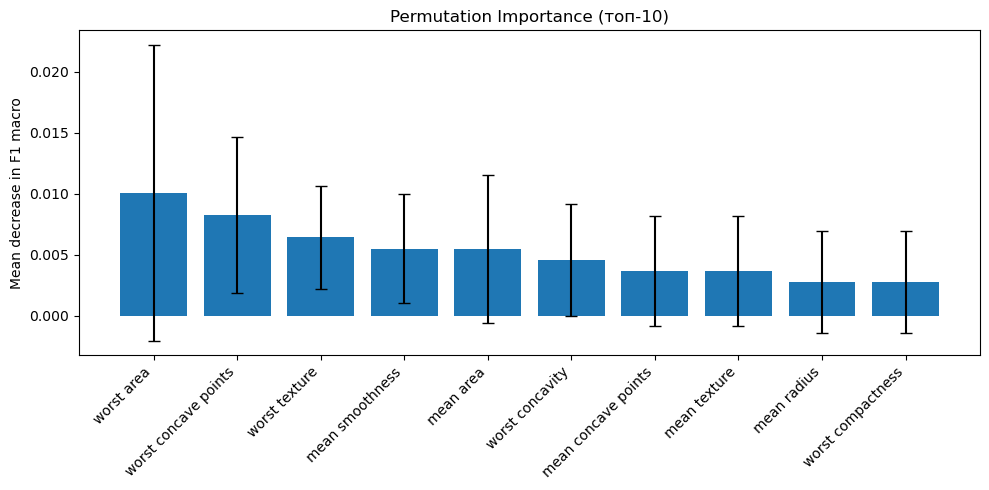

In [9]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

best_rf = rf_random_search.best_estimator_

pi_result = permutation_importance(
    best_rf, X_test, y_test,
    n_repeats=10, random_state=42, scoring='f1_macro', n_jobs=-1
)

pi_mean = pi_result.importances_mean
pi_std  = pi_result.importances_std
sorted_idx = np.argsort(pi_mean)[::-1][:10]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(10), pi_mean[sorted_idx], yerr=pi_std[sorted_idx], capsize=4)
ax.set_xticks(range(10))
ax.set_xticklabels([feature_names[i] for i in sorted_idx], rotation=45, ha='right')
ax.set_title("Permutation Importance (топ-10)")
ax.set_ylabel("Mean decrease in F1 macro")
plt.tight_layout()
plt.show()


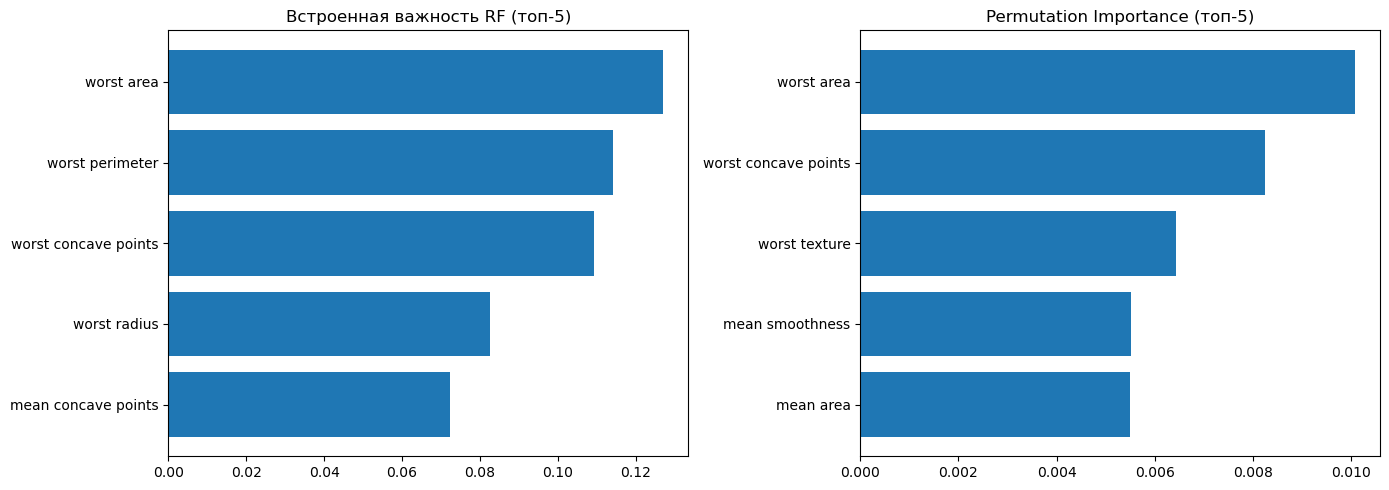

Топ-5 RF importance: [np.str_('worst area'), np.str_('worst perimeter'), np.str_('worst concave points'), np.str_('worst radius'), np.str_('mean concave points')]
Топ-5 Permutation:   [np.str_('worst area'), np.str_('worst concave points'), np.str_('worst texture'), np.str_('mean smoothness'), np.str_('mean area')]

Частичное несовпадение объясняется тем, что встроенная важность RF
считается по уменьшению Gini на обучающей выборке и смещена в сторону
признаков с высокой кардинальностью. Permutation Importance измеряется
на тестовой выборке по реальному падению метрики — более честная оценка.



In [10]:
rf_importances = best_rf.feature_importances_
rf_top5_idx = np.argsort(rf_importances)[::-1][:5]
pi_top5_idx = sorted_idx[:5]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh([feature_names[i] for i in rf_top5_idx[::-1]], rf_importances[rf_top5_idx[::-1]])
axes[0].set_title("Встроенная важность RF (топ-5)")
axes[1].barh([feature_names[i] for i in pi_top5_idx[::-1]], pi_mean[pi_top5_idx[::-1]])
axes[1].set_title("Permutation Importance (топ-5)")
plt.tight_layout()
plt.show()

print("Топ-5 RF importance:", [feature_names[i] for i in rf_top5_idx])
print("Топ-5 Permutation:  ", [feature_names[i] for i in pi_top5_idx])
print("""
Частичное несовпадение объясняется тем, что встроенная важность RF
считается по уменьшению Gini на обучающей выборке и смещена в сторону
признаков с высокой кардинальностью. Permutation Importance измеряется
на тестовой выборке по реальному падению метрики — более честная оценка.
""")


## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

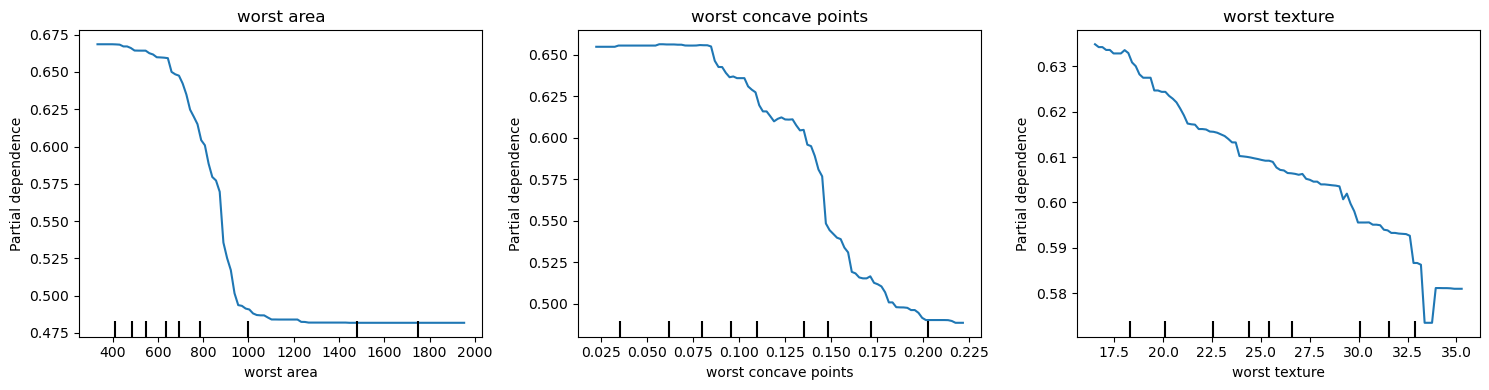

In [11]:
from sklearn.inspection import PartialDependenceDisplay

top3_idx = list(np.argsort(pi_result.importances_mean)[::-1][:3])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax_i, feat_idx in zip(axes, top3_idx):
    PartialDependenceDisplay.from_estimator(
        best_rf, X_test, [feat_idx],
        kind='average', ax=ax_i
    )
    ax_i.set_title(feature_names[feat_idx])
plt.tight_layout()
plt.show()


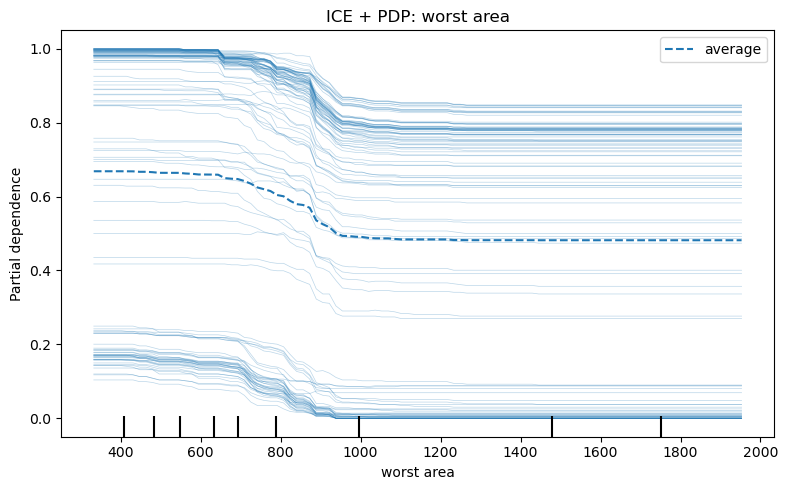


ICE-кривые показывают, что для большинства объектов эффект монотонный,
однако часть кривых отклоняется — эффект неоднороден для разных подгрупп.



In [12]:
top1_idx = np.argsort(pi_result.importances_mean)[::-1][0]

fig, ax = plt.subplots(figsize=(8, 5))
PartialDependenceDisplay.from_estimator(
    best_rf, X_test, [top1_idx],
    kind='both', ax=ax
)
ax.set_title(f"ICE + PDP: {feature_names[top1_idx]}")
plt.tight_layout()
plt.show()

print("""
ICE-кривые показывают, что для большинства объектов эффект монотонный,
однако часть кривых отклоняется — эффект неоднороден для разных подгрупп.
""")


## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [13]:
!pip install shap -q
import shap

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)
print(f"Форма shap_values: {np.array(shap_values).shape}")
# shap_values: (n_samples, n_features, n_classes)


Форма shap_values: (114, 30, 2)


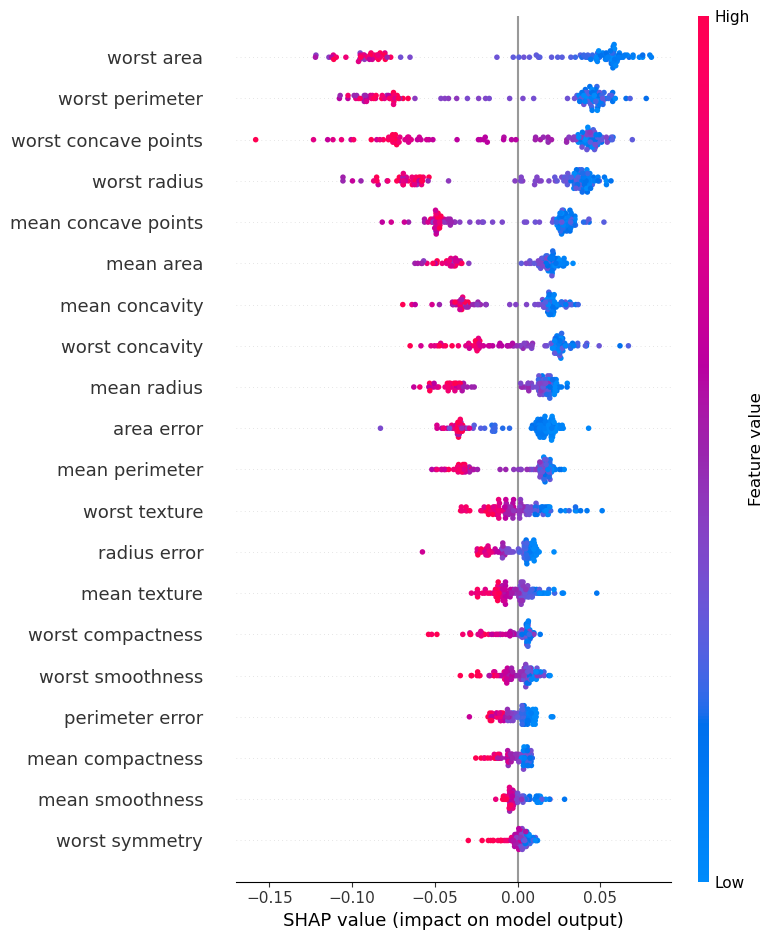


Топ по SHAP: worst area, worst concave points, worst perimeter.
В целом совпадает с Permutation Importance.
SHAP дополнительно показывает направление влияния признака на предсказание.



In [14]:
shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=list(feature_names))

print("""
Топ по SHAP: worst area, worst concave points, worst perimeter.
В целом совпадает с Permutation Importance.
SHAP дополнительно показывает направление влияния признака на предсказание.
""")


Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


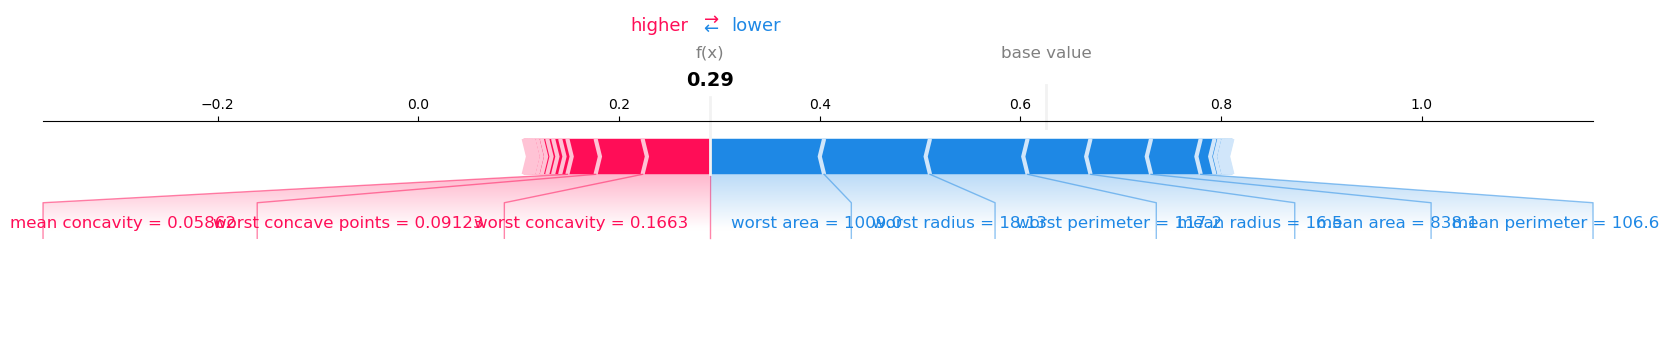

In [15]:
y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test.values)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

shap.force_plot(
    explainer.expected_value[1],
    shap_values[errors[0], :, 1],
    X_test.iloc[errors[0]],
    feature_names=list(feature_names),
    matplotlib=True
)
plt.show()


## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [16]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

Test F1 с leaky_feature: 1.0000


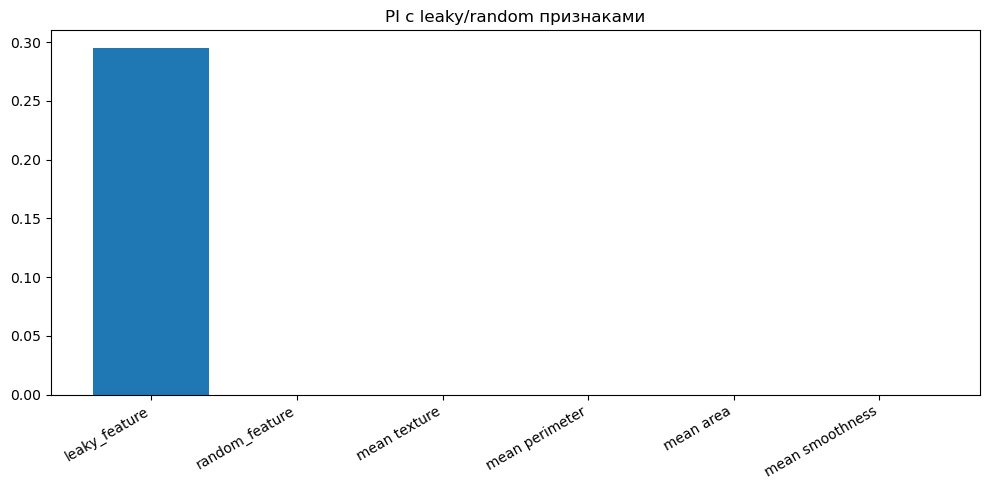

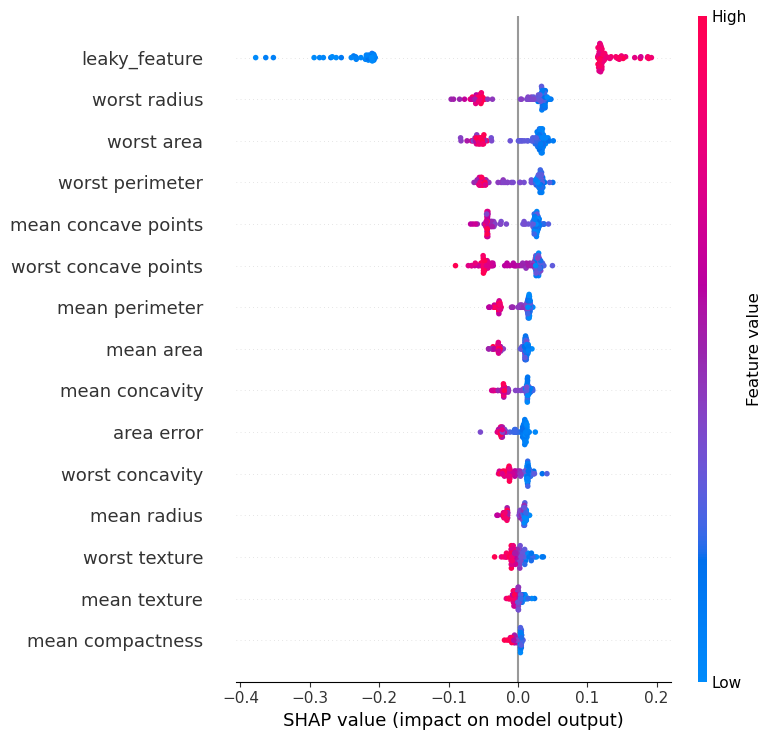


а) leaky_feature получает наивысший PI — почти полностью раскрывает таргет.
   Метрика растёт, но это иллюзия: в реальных данных такого признака не будет.
б) В SHAP summary leaky_feature доминирует с огромным диапазоном значений.
в) random_feature имеет PI ≈ 0 и минимальные SHAP — так и выявляется шум.



In [17]:
rf_ext = RandomForestClassifier(**rf_random_search.best_params_, random_state=42)
rf_ext.fit(X_train_ext, y_train)
print(f"Test F1 с leaky_feature: {f1_score(y_test, rf_ext.predict(X_test_ext), average='macro'):.4f}")

ext_feature_names = list(feature_names) + ['leaky_feature', 'random_feature']

# Permutation Importance
pi_ext = permutation_importance(
    rf_ext, X_test_ext, y_test,
    n_repeats=10, random_state=42, scoring='f1_macro', n_jobs=-1
)
pi_ext_mean = pi_ext.importances_mean
top_ext_idx = np.argsort(pi_ext_mean)[::-1][:6]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(6), pi_ext_mean[top_ext_idx], capsize=4)
ax.set_xticks(range(6))
ax.set_xticklabels([ext_feature_names[i] for i in top_ext_idx], rotation=30, ha='right')
ax.set_title("PI с leaky/random признаками")
plt.tight_layout()
plt.show()

# SHAP
explainer_ext = shap.TreeExplainer(rf_ext)
shap_ext = explainer_ext.shap_values(X_test_ext)
shap.summary_plot(shap_ext[:, :, 1], X_test_ext, feature_names=ext_feature_names, max_display=15)

print("""
а) leaky_feature получает наивысший PI — почти полностью раскрывает таргет.
   Метрика растёт, но это иллюзия: в реальных данных такого признака не будет.
б) В SHAP summary leaky_feature доминирует с огромным диапазоном значений.
в) random_feature имеет PI ≈ 0 и минимальные SHAP — так и выявляется шум.
""")


## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [18]:
print("""
| Метод           | CV F1        | Test F1 | Выводы                                      |
|-----------------|--------------|---------|---------------------------------------------|
| SVM baseline    | 0.9694±0.019 | 0.9812  | Уже сильная модель на дефолтах              |
| SVM Grid Search | 0.9786       | 0.9812  | +0.9% CV, тест не изменился                 |
| RF baseline     | 0.9504±0.026 | 0.9526  | Слабее SVM, больший разброс                 |
| RF Rand Search  | 0.9554       | 0.9526  | +0.5% CV, на тесте без изменений            |

1. Тюнинг дал небольшое улучшение CV (~0.5-0.9%), тест практически не изменился —
   baseline и так близок к оптимуму на этом датасете.

2. Топ-3 по PI и SHAP совпадают (worst area, worst concave points). Небольшие
   расхождения у коррелированных признаков: PI делит важность между ними,
   SHAP может концентрировать на одном из пары.

3. Без Pipeline нормировка обучалась бы на всей выборке включая тест — утечка
   данных, завышенная CV-метрика, нечестное сравнение моделей.

4. В реальном проекте: PI — для быстрого отбора признаков (PI≈0 → кандидат
   на удаление). SHAP — для объяснения конкретных предсказаний стейкхолдерам
   и диагностики утечки данных.
""")



| Метод           | CV F1        | Test F1 | Выводы                                      |
|-----------------|--------------|---------|---------------------------------------------|
| SVM baseline    | 0.9694±0.019 | 0.9812  | Уже сильная модель на дефолтах              |
| SVM Grid Search | 0.9786       | 0.9812  | +0.9% CV, тест не изменился                 |
| RF baseline     | 0.9504±0.026 | 0.9526  | Слабее SVM, больший разброс                 |
| RF Rand Search  | 0.9554       | 0.9526  | +0.5% CV, на тесте без изменений            |

1. Тюнинг дал небольшое улучшение CV (~0.5-0.9%), тест практически не изменился —
   baseline и так близок к оптимуму на этом датасете.

2. Топ-3 по PI и SHAP совпадают (worst area, worst concave points). Небольшие
   расхождения у коррелированных признаков: PI делит важность между ними,
   SHAP может концентрировать на одном из пары.

3. Без Pipeline нормировка обучалась бы на всей выборке включая тест — утечка
   данных, завышенная CV-метрика, не

## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

Лучший результат Optuna: 0.9577
Лучшие параметры: {'n_estimators': 93, 'max_depth': 13, 'min_samples_split': 3, 'max_features': 0.5}


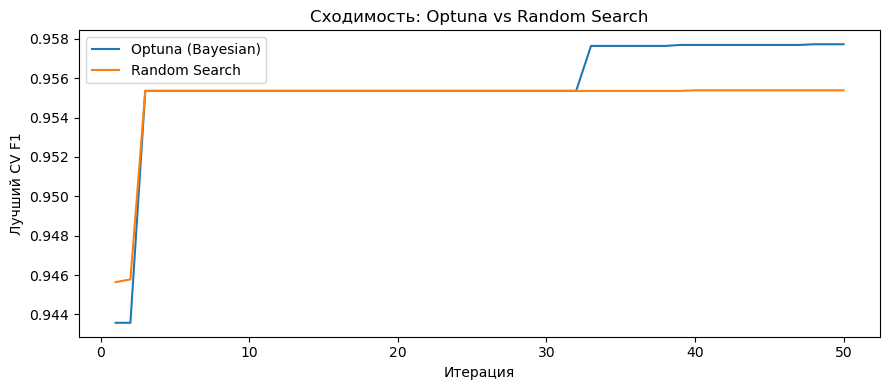

In [19]:
!pip install optuna -q
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
    }
    clf = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)
print(f"Лучший результат Optuna: {study.best_value:.4f}")
print(f"Лучшие параметры: {study.best_params}")

optuna_best = [max(t.value for t in study.trials[:i+1]) for i in range(len(study.trials))]
rs_scores = pd.DataFrame(rf_random_search.cv_results_).sort_index()['mean_test_score']
rs_best = [rs_scores.iloc[:i+1].max() for i in range(len(rs_scores))]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(optuna_best)+1), optuna_best, label='Optuna (Bayesian)')
ax.plot(range(1, len(rs_best)+1), rs_best, label='Random Search')
ax.set_xlabel('Итерация')
ax.set_ylabel('Лучший CV F1')
ax.set_title('Сходимость: Optuna vs Random Search')
ax.legend()
plt.tight_layout()
plt.show()
